# 03 — Probability Distributions
**References:** Johnson, Kotz & Balakrishnan (1994) · Casella & Berger (2002)

## Narrative thread
```
Discrete distributions -> Continuous distributions -> Relationships between them -> CLT preview
```

## Discrete distributions

| Distribution | PMF | $E[X]$ | $\text{Var}(X)$ | Use |
|---|---|---|---|---|
| **Bernoulli($p$)** | $p^x(1-p)^{1-x}$ | $p$ | $p(1-p)$ | Single binary trial |
| **Binomial($n,p$)** | $\binom{n}{x}p^x(1-p)^{n-x}$ | $np$ | $np(1-p)$ | Count of successes in $n$ trials |
| **Poisson($\lambda$)** | $e^{-\lambda}\lambda^x/x!$ | $\lambda$ | $\lambda$ | Count of rare events per unit time |
| **Geometric($p$)** | $(1-p)^{x-1}p$ | $1/p$ | $(1-p)/p^2$ | Trials until first success |

## Continuous distributions

| Distribution | PDF | $E[X]$ | $\text{Var}(X)$ | Use |
|---|---|---|---|---|
| **Uniform($a,b$)** | $1/(b-a)$ | $(a+b)/2$ | $(b-a)^2/12$ | Equal probability over interval |
| **Normal($\mu,\sigma^2$)** | $\frac{1}{\sigma\sqrt{2\pi}}e^{-(x-\mu)^2/2\sigma^2}$ | $\mu$ | $\sigma^2$ | Sums by CLT; many natural phenomena |
| **Exponential($\lambda$)** | $\lambda e^{-\lambda x}$ | $1/\lambda$ | $1/\lambda^2$ | Time until next event (memoryless) |
| **$t_\nu$** | — | $0$ ($\nu>1$) | $\nu/(\nu-2)$ ($\nu>2$) | Small-sample inference |
| **$\chi^2_\nu$** | — | $\nu$ | $2\nu$ | Variance estimation, goodness-of-fit |
| **$F_{d_1,d_2}$** | — | $d_2/(d_2-2)$ | — | Ratio of variances, ANOVA |

## Relationships

$$\text{Bin}(n,p) \xrightarrow{n\to\infty} N(np, np(1-p)) \qquad \text{Poisson}(\lambda) \xrightarrow{\lambda\to\infty} N(\lambda, \lambda)$$
$$Z = \frac{X-\mu}{\sigma} \sim N(0,1) \qquad \chi^2_\nu = \sum_{i=1}^\nu Z_i^2 \qquad t_\nu = \frac{Z}{\sqrt{\chi^2_\nu/\nu}} \qquad F_{d_1,d_2} = \frac{\chi^2_{d_1}/d_1}{\chi^2_{d_2}/d_2}$$

In [1]:
import os
os.chdir('/Volumes/SSD_Gabo/proyectos/growth-analytics')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams.update({
    'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#e8e8e8', 'axes.axisbelow': True,
    'axes.titlesize': 11, 'axes.titleweight': 'bold', 'legend.frameon': False,
})
np.random.seed(42)

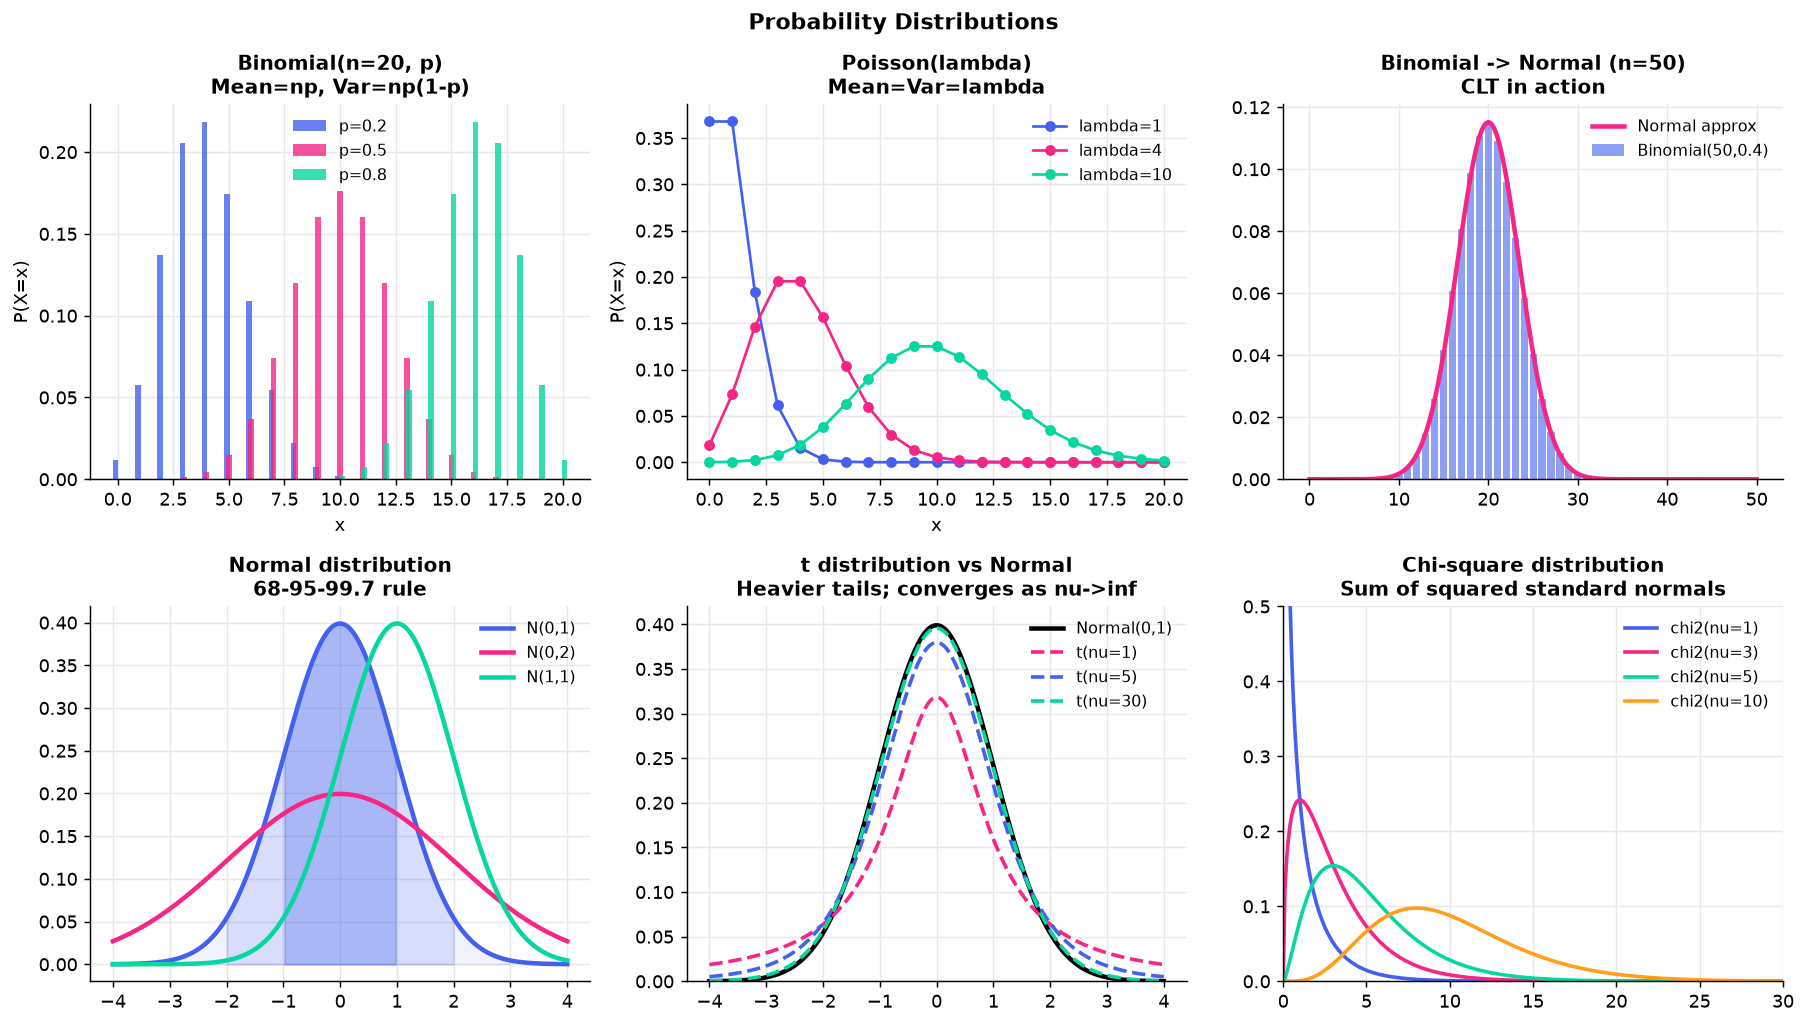

In [2]:
from scipy.stats import binom, poisson, norm, expon, t as t_dist, chi2, f as f_dist

# ── Discrete: Binomial and Poisson ───────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# Binomial PMF for different p
x_b = np.arange(0, 21)
for p, c in [(0.2,'#4361ee'), (0.5,'#f72585'), (0.8,'#06d6a0')]:
    pmf = binom.pmf(x_b, n=20, p=p)
    axes[0,0].bar(x_b + (p-0.5)*0.3, pmf, width=0.25, alpha=0.8, color=c, label=f'p={p}')
axes[0,0].set_xlabel('x'); axes[0,0].set_ylabel('P(X=x)')
axes[0,0].set_title('Binomial(n=20, p)\nMean=np, Var=np(1-p)')
axes[0,0].legend(fontsize=9)

# Poisson PMF for different lambda
x_p = np.arange(0, 21)
for lam, c in [(1,'#4361ee'), (4,'#f72585'), (10,'#06d6a0')]:
    axes[0,1].plot(x_p, poisson.pmf(x_p, lam), 'o-', color=c, lw=1.5, ms=5, label=f'lambda={lam}')
axes[0,1].set_xlabel('x'); axes[0,1].set_ylabel('P(X=x)')
axes[0,1].set_title('Poisson(lambda)\nMean=Var=lambda')
axes[0,1].legend(fontsize=9)

# Binomial -> Normal approximation
n_big, p_big = 50, 0.4
x_bn = np.arange(0, n_big+1)
x_cont = np.linspace(0, n_big, 300)
axes[0,2].bar(x_bn, binom.pmf(x_bn, n_big, p_big), alpha=0.6, color='#4361ee', label='Binomial(50,0.4)')
axes[0,2].plot(x_cont, norm.pdf(x_cont, n_big*p_big, np.sqrt(n_big*p_big*(1-p_big))),
               color='#f72585', lw=2.5, label='Normal approx')
axes[0,2].set_title('Binomial -> Normal (n=50)\nCLT in action')
axes[0,2].legend(fontsize=9)

# Normal PDF
x_n = np.linspace(-4, 4, 300)
for mu, sigma, c, lab in [(0,1,'#4361ee','N(0,1)'), (0,2,'#f72585','N(0,2)'), (1,1,'#06d6a0','N(1,1)')]:
    axes[1,0].plot(x_n, norm.pdf(x_n, mu, sigma), color=c, lw=2.5, label=lab)
axes[1,0].set_title('Normal distribution\n68-95-99.7 rule')
axes[1,0].legend(fontsize=9)
# Shade +/- 1,2,3 sigma for N(0,1)
for k, alpha in [(1,0.3),(2,0.15),(3,0.07)]:
    axes[1,0].fill_between(x_n, norm.pdf(x_n), where=(np.abs(x_n)<=k),
                            color='#4361ee', alpha=alpha)

# t distribution vs Normal
x_t = np.linspace(-4, 4, 300)
axes[1,1].plot(x_t, norm.pdf(x_t), color='black', lw=2.5, label='Normal(0,1)')
for nu, c in [(1,'#f72585'), (5,'#4361ee'), (30,'#06d6a0')]:
    axes[1,1].plot(x_t, t_dist.pdf(x_t, nu), color=c, lw=2, linestyle='--', label=f't(nu={nu})')
axes[1,1].set_title('t distribution vs Normal\nHeavier tails; converges as nu->inf')
axes[1,1].legend(fontsize=9); axes[1,1].set_ylim(0, 0.42)

# Chi-square
x_c = np.linspace(0, 30, 300)
for nu, c in [(1,'#4361ee'), (3,'#f72585'), (5,'#06d6a0'), (10,'#ff9f1c')]:
    axes[1,2].plot(x_c, chi2.pdf(x_c, nu), color=c, lw=2, label=f'chi2(nu={nu})')
axes[1,2].set_xlim(0, 30); axes[1,2].set_ylim(0, 0.5)
axes[1,2].set_title('Chi-square distribution\nSum of squared standard normals')
axes[1,2].legend(fontsize=9)

plt.suptitle('Probability Distributions', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## The Normal distribution in depth

### 68-95-99.7 rule
$$P(\mu - \sigma < X < \mu + \sigma) \approx 0.683$$
$$P(\mu - 2\sigma < X < \mu + 2\sigma) \approx 0.954$$
$$P(\mu - 3\sigma < X < \mu + 3\sigma) \approx 0.997$$

### Standardization
Any $X \sim N(\mu, \sigma^2)$ can be converted to $Z \sim N(0,1)$:
$$Z = \frac{X - \mu}{\sigma} \implies P(X \leq x) = \Phi\left(\frac{x-\mu}{\sigma}\right)$$

### Log-normal
If $\ln X \sim N(\mu, \sigma^2)$, then $X \sim \text{LogNormal}(\mu, \sigma^2)$:
$$E[X] = e^{\mu + \sigma^2/2} \qquad \text{Median} = e^\mu$$
Income, stock prices, and many biological measurements are log-normal.

In [3]:
# ── CDF, quantiles, and the 68-95-99.7 rule ─────────────────────────────
print('Normal distribution: key quantiles')
for p in [0.025, 0.05, 0.10, 0.90, 0.95, 0.975]:
    print(f'  Phi^-1({p:.3f}) = {norm.ppf(p):.4f}')

print()
print('68-95-99.7 rule (verified numerically):')
for k in [1, 2, 3]:
    prob = norm.cdf(k) - norm.cdf(-k)
    print(f'  P(|Z| <= {k}) = {prob:.6f}  ({prob*100:.3f}%)')

print()
print('Exponential distribution (memoryless property):')
lam = 0.5   # rate: avg 2 minutes between events
print(f'  P(X > 3) = {1 - expon.cdf(3, scale=1/lam):.4f}')
print(f'  P(X > 5 | X > 2) = P(X > 3) = {1 - expon.cdf(3, scale=1/lam):.4f}  (memoryless!)')
print(f'  Mean waiting time = 1/lambda = {1/lam:.1f}')

Normal distribution: key quantiles
  Phi^-1(0.025) = -1.9600
  Phi^-1(0.050) = -1.6449
  Phi^-1(0.100) = -1.2816
  Phi^-1(0.900) = 1.2816
  Phi^-1(0.950) = 1.6449
  Phi^-1(0.975) = 1.9600

68-95-99.7 rule (verified numerically):
  P(|Z| <= 1) = 0.682689  (68.269%)
  P(|Z| <= 2) = 0.954500  (95.450%)
  P(|Z| <= 3) = 0.997300  (99.730%)

Exponential distribution (memoryless property):
  P(X > 3) = 0.2231
  P(X > 5 | X > 2) = P(X > 3) = 0.2231  (memoryless!)
  Mean waiting time = 1/lambda = 2.0
